# LAB_QI XGBoost Backcasting

Non-linear backcasting of LAB_QI for pre-2008 using XGBoost. Uses only predictors with good pre-2008 coverage; no median imputation (XGBoost handles NA natively).

Graphs compare imputed vs observed HC (LAB_QI) movement over time.

## 1. Setup & Load Data

In [59]:
library(knitr)
dir.create("output/tables", showWarnings = FALSE, recursive = TRUE)
dir.create("output/figures", showWarnings = FALSE, recursive = TRUE)

In [60]:
library(tidyverse)
library(data.table)
library(xgboost)

broad_sectors <- c("A", "B", "C", "D-E", "F", "G", "H", "I", "J", "K", "L", "M-N", "O-Q", "R-S")

sector_display_names <- c(
  "A" = "A – Agriculture",
  "B" = "B – Mining & quarrying",
  "C" = "C – Manufacturing",
  "D-E" = "D-E – Utilities",
  "F" = "F – Construction",
  "G" = "G – Wholesale & retail trade",
  "H" = "H – Transport & storage",
  "I" = "I – Accommodation & food",
  "J" = "J – ICT",
  "K" = "K – Finance & insurance",
  "L" = "L – Real estate",
  "M-N" = "M-N – Professional services",
  "O-Q" = "O-Q – Public admin, education, health",
  "R-S" = "R-S – Arts & other services"
)

fp <- fread("Data/final_panel.csv")
fp <- fp[nace_r2_code %in% broad_sectors]
cat("Restricted to", length(broad_sectors), "broad sectors. Rows:", nrow(fp), "\n")
cat("LAB_QI observed (2008+):", sum(!is.na(fp$valueLAB_QI)), "| Range:", round(range(fp$valueLAB_QI, na.rm = TRUE), 1), "\n")

Restricted to 14 broad sectors. Rows: 378 
LAB_QI observed (2008+): 196 | Range: 63.4 148.6 


## 2. Predictor Selection (Good Pre-2008 Coverage)

In [61]:
# Pre-2008 rows (broad sectors only)
pred_rows <- fp[year < 2008]

excl <- c("valueLAB_QI", "nace_r2_name", "nace_r2_name.x", "nace_r2_name.y")
cand <- setdiff(names(fp), excl)

cov_pre <- sapply(cand, function(v) {
  if (is.character(pred_rows[[v]]) || is.factor(pred_rows[[v]])) 100
  else 100 * sum(!is.na(pred_rows[[v]])) / nrow(pred_rows)
})

pred_cols <- names(cov_pre)[cov_pre >= 80]
cat("Predictors with >=80% pre-2008 coverage:", length(pred_cols), "\n")
cat("Sample:", paste(head(pred_cols, 15), collapse = ", "), "\n")

Predictors with >=80% pre-2008 coverage: 109 
Sample: year, nace_r2_code, valI_Cult, valI_GFCF, valI_OCon, valI_OIPP, valI_OMach, valI_RD, valI_Rstruc, valI_Soft_DB, valI_TraEq, valIp_Cult, valIp_GFCF, valIp_OCon, valIp_OIPP 


## 3. Prepare Train & Predict Sets

In [62]:
train_df <- fp[year >= 2008 & !is.na(valueLAB_QI)]
pred_df  <- fp[year < 2008]

# Numeric predictors only (XGBoost needs numeric matrix); exclude nace_r2_code (use nace_num)
num_cols <- c("year")
for (v in setdiff(pred_cols, c("year", "nace_r2_code"))) {
  if (is.numeric(fp[[v]]) || is.integer(fp[[v]])) num_cols <- c(num_cols, v)
}

# nace_r2_code: label encode (factor -> integer)
all_nace <- unique(c(train_df$nace_r2_code, pred_df$nace_r2_code))
nace_map <- setNames(seq_along(all_nace), all_nace)
train_df$nace_num <- as.integer(nace_map[train_df$nace_r2_code])
pred_df$nace_num  <- as.integer(nace_map[pred_df$nace_r2_code])

# Build feature matrix: numeric cols + nace_num
feat_cols <- c("year", "nace_num", setdiff(num_cols, c("year", "nace_r2_code")))
feat_cols <- intersect(feat_cols, names(train_df))

X_train <- as.matrix(train_df[, ..feat_cols])
y_train <- train_df$valueLAB_QI
X_pred  <- as.matrix(pred_df[, ..feat_cols])

# Normalise predictors (z-score from training data) — avoids scale dominance
col_mean <- colMeans(X_train, na.rm = TRUE)
col_sd   <- apply(X_train, 2, sd, na.rm = TRUE)
col_sd[col_sd == 0 | !is.finite(col_sd)] <- 1
X_train  <- scale(X_train, center = col_mean, scale = col_sd)
X_pred   <- scale(X_pred,  center = col_mean, scale = col_sd)

cat("Train:", nrow(X_train), "x", ncol(X_train), "| Pred:", nrow(X_pred), "\n")

Train: 196 x 109 | Pred: 182 


## 3b. Hyperparameter Tuning

Random search over parameter grid with 5-fold CV and early stopping. Select best combination by CV RMSE.

In [63]:
# XGBoost accepts NA; store as NA explicitly
dtrain <- xgb.DMatrix(data = X_train, label = y_train)

# Parameter grid (plan: max_depth 2-8, eta, subsample, colsample_bytree, min_child_weight)
set.seed(42)
grid <- expand.grid(
  max_depth = c(2, 3, 4, 5, 6, 7, 8),
  eta = c(0.03, 0.05, 0.08, 0.1),
  subsample = c(0.6, 0.75, 0.9),
  colsample_bytree = c(0.6, 0.75, 0.9),
  min_child_weight = c(1, 3, 5)
)
# Random subset to keep tuning tractable (~28 combos)
grid <- grid[sample(nrow(grid), min(28, nrow(grid))), ]

results <- vector("list", nrow(grid))
for (i in seq_len(nrow(grid))) {
  p <- as.list(grid[i, ])
  p$objective <- "reg:squarederror"
  p$max_depth <- as.integer(p$max_depth)
  p$min_child_weight <- as.integer(p$min_child_weight)
  cv <- xgb.cv(
    data = dtrain,
    nfold = 5,
    params = p,
    nrounds = 500,
    early_stopping_rounds = 25,
    verbose = 0
  )
  best_iter <- cv$early_stop$best_iteration
  test_col <- grep("^test", names(cv$evaluation_log), value = TRUE)[1]
  if (is.null(best_iter)) best_iter <- which.min(cv$evaluation_log[[test_col]])
  rmse <- min(cv$evaluation_log[[test_col]])
  results[[i]] <- c(grid[i, ], rmse = rmse, best_iter = best_iter)
}

res_df <- do.call(rbind, lapply(results, as.data.frame))
res_df <- res_df[order(res_df$rmse), ]
best_row <- res_df[1, ]

best_params <- list(
  objective = "reg:squarederror",
  max_depth = as.integer(best_row$max_depth),
  eta = best_row$eta,
  subsample = best_row$subsample,
  colsample_bytree = best_row$colsample_bytree,
  min_child_weight = as.integer(best_row$min_child_weight)
)
best_nrounds <- as.integer(best_row$best_iter)

cat("Best params: max_depth =", best_params$max_depth, ", eta =", best_params$eta,
    ", subsample =", best_params$subsample, ", colsample_bytree =", best_params$colsample_bytree,
    ", min_child_weight =", best_params$min_child_weight, "\n")
cat("Best nrounds:", best_nrounds, "| CV RMSE:", round(best_row$rmse, 4), "\n")
cat("\nTop 5 combinations by CV RMSE:\n")
tbl_hp <- head(res_df[, c("max_depth", "eta", "subsample", "colsample_bytree", "min_child_weight", "rmse")], 5)
print(tbl_hp)
tbl_tex <- knitr::kable(tbl_hp, format = "latex", digits = 4, booktabs = TRUE)
writeLines(tbl_tex, "output/tables/hyperparameter_top5.tex")

Best params: max_depth = 5 , eta = 0.08 , subsample = 0.9 , colsample_bytree = 0.75 , min_child_weight = 3 
Best nrounds: 498 | CV RMSE: 6.633 

Top 5 combinations by CV RMSE:
   max_depth  eta subsample colsample_bytree min_child_weight     rmse
17         5 0.08      0.90             0.75                3 6.633045
11         4 0.10      0.60             0.60                1 6.773110
19         3 0.08      0.90             0.90                5 6.793725
8          8 0.08      0.75             0.60                1 6.858368
20         4 0.03      0.75             0.60                3 6.892824


## 4. Train XGBoost & Predict

## 5b. RMSE on Observed Data (5-fold CV)

5-fold cross-validation on the 2008+ observed set to assess model fit.

In [64]:
# 5-fold CV RMSE on observed (2008+) data
set.seed(42)
n_train <- nrow(X_train)
k <- 5
folds <- sample(rep(seq_len(k), length.out = n_train))
cv_pred <- numeric(n_train)
for (fold in seq_len(k)) {
  idx_tr <- which(folds != fold)
  idx_te <- which(folds == fold)
  dt_tr <- xgb.DMatrix(data = X_train[idx_tr, ], label = y_train[idx_tr])
  fit_cv <- xgb.train(best_params, dt_tr, nrounds = best_nrounds, verbose = 0)
  cv_pred[idx_te] <- predict(fit_cv, xgb.DMatrix(data = X_train[idx_te, , drop = FALSE]))
}
rmse_cv <- sqrt(mean((y_train - cv_pred)^2))
cat(sprintf("5-fold CV RMSE on observed LAB_QI (2008+): %.3f\n", rmse_cv))

5-fold CV RMSE on observed LAB_QI (2008+): 7.659


## 5c. Per-Sector Leave-One-Sector-Out RMSE

Leave-one-sector-out CV: for each sector, train on all other sectors (2008+), predict for the held-out sector, compute RMSE in index points.

In [65]:
# Leave-one-sector-out CV for per-sector RMSE
set.seed(42)
sector_rmse_list <- vector("list", length(broad_sectors))
for (i in seq_along(broad_sectors)) {
  s <- broad_sectors[i]
  tr_loo <- train_df[nace_r2_code != s]
  te_loo <- train_df[nace_r2_code == s]
  X_tr <- as.matrix(tr_loo[, ..feat_cols])
  X_te <- as.matrix(te_loo[, ..feat_cols])
  y_tr <- tr_loo$valueLAB_QI
  y_te <- te_loo$valueLAB_QI
  # Scale using full-train col_mean, col_sd
  X_tr <- scale(X_tr, center = col_mean, scale = col_sd)
  X_te <- scale(X_te, center = col_mean, scale = col_sd)
  dt_tr <- xgb.DMatrix(data = X_tr, label = y_tr)
  fit_loo <- xgb.train(best_params, dt_tr, nrounds = best_nrounds, verbose = 0)
  pred_te <- predict(fit_loo, xgb.DMatrix(data = X_te))
  rmse_s <- sqrt(mean((y_te - pred_te)^2))
  sector_rmse_list[[i]] <- data.frame(sector = s, RMSE = rmse_s)
}
sector_rmse <- do.call(rbind, sector_rmse_list)
sector_rmse <- sector_rmse[order(sector_rmse$RMSE), ]
# Export LaTeX
tbl_tex <- knitr::kable(sector_rmse, format = "latex", digits = 2, booktabs = TRUE,
  col.names = c("Sector", "RMSE (index pts)"), row.names = FALSE)
writeLines(tbl_tex, "output/tables/sector_rmse_xgb.tex")
cat("Per-sector LOO RMSE (sorted):\n")
print(sector_rmse)
cat("\nLowest 3 (most reliable):", paste(sector_rmse$sector[1:3], "(", round(sector_rmse$RMSE[1:3], 2), ")", sep = "", collapse = ", "), "\n")
cat("Highest 3 (most uncertainty):", paste(sector_rmse$sector[12:14], "(", round(sector_rmse$RMSE[12:14], 2), ")", sep = "", collapse = ", "), "\n")
cat("Exported output/tables/sector_rmse_xgb.tex\n")

Per-sector LOO RMSE (sorted):
   sector      RMSE
7       H  3.701912
13    O-Q  5.733473
11      L  6.542264
4     D-E  6.755511
3       C  8.001490
6       G  9.449665
10      K  9.839540
14    R-S 11.844300
8       I 12.766447
1       A 13.674591
2       B 15.315380
12    M-N 16.746070
5       F 16.764074
9       J 17.536836

Lowest 3 (most reliable): H(3.7), O-Q(5.73), L(6.54) 
Highest 3 (most uncertainty): M-N(16.75), F(16.76), J(17.54) 
Exported output/tables/sector_rmse_xgb.tex


In [66]:
# Train final model with best params from tuning (dtrain already created in Section 3b)
set.seed(42)
fit <- xgb.train(best_params, dtrain, nrounds = best_nrounds, verbose = 0)

pred_raw <- predict(fit, xgb.DMatrix(data = X_pred))
# Clip to observed LAB_QI range (broad sectors: ~63–149)
labqi_lo <- max(50, min(y_train) - 10)
labqi_hi <- min(200, max(y_train) + 10)
pred_df$valueLAB_QI_imputed <- pmax(labqi_lo, pmin(labqi_hi, pred_raw))
cat("Imputed", nrow(pred_df), "values. Range:", round(range(pred_df$valueLAB_QI_imputed), 2), "\n")

Imputed 182 values. Range: 69.9 123.3 


## 5. Merge & Build Full Series

In [67]:
# Observed: 2008+
obs <- train_df[, .(nace_r2_code, year, valueLAB_QI)]
obs$source <- "observed"

# Imputed: pre-2008
imp <- pred_df[, .(nace_r2_code, year, valueLAB_QI = valueLAB_QI_imputed)]
imp$source <- "imputed"

full <- rbind(obs[, .(nace_r2_code, year, valueLAB_QI, source)],
              imp[, .(nace_r2_code, year, valueLAB_QI, source)])
full <- full[order(nace_r2_code, year)]

# Growth rates for movement comparison
full <- full[, g_LABQI := (log(valueLAB_QI) - log(shift(valueLAB_QI))) * 100, by = nace_r2_code]

cat("Full series:", nrow(full), "rows\n")
cat("Industries:", length(unique(full$nace_r2_code)), "\n")

Full series: 378 rows
Industries: 14 


## 6b. Growth Accounting (Question c): Evolution Over Time

Decompose growth in output per hour between capital, human capital, and TFP: $\hat{y} = \frac{\alpha}{1-\alpha}(\hat{K}-\hat{L}) + \hat{h} + \hat{A}$ with $\alpha=1/3$. Uses imputed LAB_QI for pre-2008.

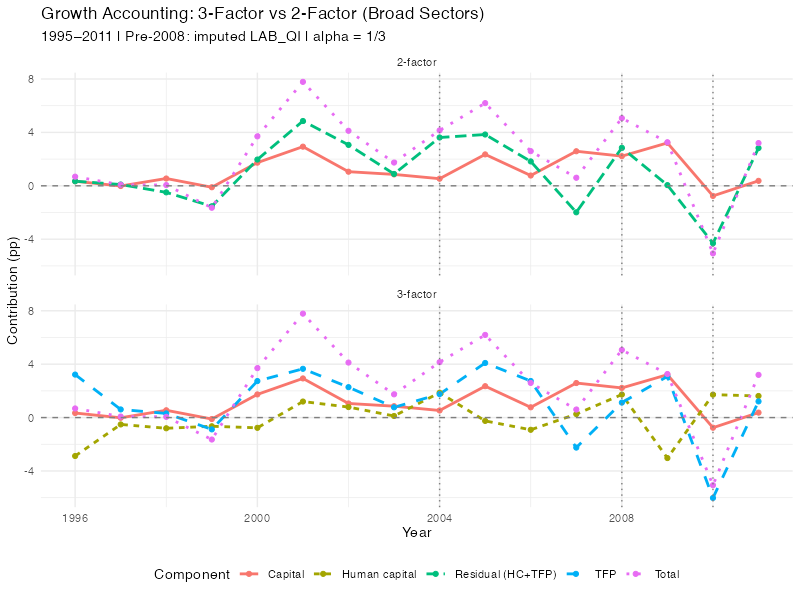

In [68]:
# Merge full LAB_QI series (imputed + observed) with panel for VA, hours, capital
decomp_df <- fp |>
  select(nace_r2_code, year, valVA_CP, valVA_Q, valH_EMP, valEMP, valEMPE, valKq_GFCF) |>
  left_join(full |> select(nace_r2_code, year, LAB_QI = valueLAB_QI), by = c("nace_r2_code", "year")) |>
  filter(nace_r2_code %in% broad_sectors, year >= 1995, year <= 2011)

# total_hours = H_EMP * (EMP / EMPE)
decomp_df <- decomp_df |>
  mutate(total_hours = valH_EMP * (valEMP / valEMPE))

alpha <- 1/3
decomp_df <- decomp_df |>
  group_by(nace_r2_code) |>
  arrange(year) |>
  mutate(
    base_va = valVA_CP[year == min(year[!is.na(valVA_CP)])][1],
    VA_real = (valVA_Q / 100) * base_va,
    y = VA_real / total_hours,
    g_y = (log(y) - log(dplyr::lag(y))) * 100,
    g_K = (log(valKq_GFCF) - log(dplyr::lag(valKq_GFCF))) * 100,
    g_L = (log(total_hours) - log(dplyr::lag(total_hours))) * 100,
    cap_contrib = (alpha / (1 - alpha)) * (g_K - g_L),
    g_h = (log(LAB_QI) - log(dplyr::lag(LAB_QI))) * 100,
    hc_contrib = g_h,
    tfp_contrib = g_y - cap_contrib - hc_contrib,
    cap_contrib_2f = cap_contrib,
    tfp_2f = g_y - cap_contrib
  ) |>
  ungroup()

# Aggregate across sectors (VA-weighted or simple mean) for evolution over time
decomp_agg <- decomp_df |>
  filter(!is.na(tfp_contrib)) |>
  group_by(year) |>
  summarise(
    cap = mean(cap_contrib, na.rm = TRUE),
    hc = mean(hc_contrib, na.rm = TRUE),
    tfp = mean(tfp_contrib, na.rm = TRUE),
    total = mean(g_y, na.rm = TRUE),
    cap_2f = mean(cap_contrib_2f, na.rm = TRUE),
    tfp_2f = mean(tfp_2f, na.rm = TRUE),
    .groups = "drop"
  )

# Long data for 3-factor and 2-factor (for facet comparison)
agg_3f <- decomp_agg |>
  select(year, cap, hc, tfp, total) |>
  pivot_longer(-year, names_to = "component", values_to = "contrib") |>
  mutate(component = recode(component, cap = "Capital", hc = "Human capital", tfp = "TFP", total = "Total"), method = "3-factor")
agg_2f <- decomp_agg |>
  select(year, cap_2f, tfp_2f, total) |>
  rename(cap = cap_2f, tfp = tfp_2f) |>
  pivot_longer(-year, names_to = "component", values_to = "contrib") |>
  mutate(component = recode(component, cap = "Capital", tfp = "Residual (HC+TFP)", total = "Total"), method = "2-factor")
agg_plot <- bind_rows(agg_3f, agg_2f)

events <- data.frame(year = c(2004, 2008, 2010), event = c("EU Accession", "GFC", "Orban gov"))
events_lab <- events |> tidyr::crossing(method = unique(agg_plot$method))

p <- ggplot(agg_plot, aes(x = year, y = contrib, colour = component, linetype = component)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey50") +
  geom_vline(data = events, aes(xintercept = year), linetype = "dotted", colour = "grey50", linewidth = 0.5) +
  geom_text(data = events_lab, aes(x = year, y = Inf, label = event), vjust = -0.5, size = 2.5, colour = "grey40", inherit.aes = FALSE) +
  facet_wrap(~ method, ncol = 1) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.12))) +
  labs(title = "Growth Accounting: 3-Factor vs 2-Factor (Broad Sectors)",
       subtitle = "1995–2011 | Pre-2008: imputed LAB_QI | alpha = 1/3",
       x = "Year", y = "Contribution (pp)", colour = "Component", linetype = "Component") +
  theme_minimal() +
  theme(legend.position = "bottom")
ggsave("output/figures/growth_accounting_3f_and_2f_line.png", p, width = 8, height = 6, dpi = 150)
p

In [69]:
# Aggregate tally table and 2-factor comparison (1995–2011)
decomp_agg_2f <- decomp_df |>
  filter(!is.na(tfp_2f)) |>
  group_by(year) |>
  summarise(
    cap_2f = mean(cap_contrib_2f, na.rm = TRUE),
    tfp_2f = mean(tfp_2f, na.rm = TRUE),
    g_y = mean(g_y, na.rm = TRUE),
    .groups = "drop"
  )

# Period-average tally: 3-factor and 2-factor
decomp_agg_wide <- decomp_df |>
  filter(!is.na(tfp_contrib)) |>
  summarise(
    LP_growth = mean(g_y, na.rm = TRUE),
    Capital = mean(cap_contrib, na.rm = TRUE),
    HC = mean(hc_contrib, na.rm = TRUE),
    TFP = mean(tfp_contrib, na.rm = TRUE),
    Capital_2f = mean(cap_contrib_2f, na.rm = TRUE),
    Residual_2f = mean(tfp_2f, na.rm = TRUE)
  )

cat("--- Aggregate Tally Table (1995–2011, period average) ---\n")
tbl_agg <- decomp_agg_wide |> mutate(across(where(is.numeric), ~round(., 2)))
print(tbl_agg)
tbl_tex <- knitr::kable(tbl_agg, format = "latex", digits = 2, booktabs = TRUE)
writeLines(tbl_tex, "output/tables/aggregate_tally.tex")

cat("\n--- 2-Factor vs 3-Factor Comparison ---\n")
cat("3-factor: Capital =", round(decomp_agg_wide$Capital, 2), "| HC =", round(decomp_agg_wide$HC, 2), "| TFP =", round(decomp_agg_wide$TFP, 2), "\n")
cat("2-factor: Capital =", round(decomp_agg_wide$Capital_2f, 2), "| Residual =", round(decomp_agg_wide$Residual_2f, 2), "(= HC + TFP)\n")

--- Aggregate Tally Table (1995–2011, period average) ---
# A tibble: 1 × 6
  LP_growth Capital    HC   TFP Capital_2f Residual_2f
      <dbl>   <dbl> <dbl> <dbl>      <dbl>       <dbl>
1      2.28    1.16 -0.03  1.15       1.16        1.12

--- 2-Factor vs 3-Factor Comparison ---
3-factor: Capital = 1.16 | HC = -0.03 | TFP = 1.15 
2-factor: Capital = 1.16 | Residual = 1.12 (= HC + TFP)


In [70]:
# Year-by-year tally table (3-factor and 2-factor)
year_tally <- decomp_df |>
  filter(!is.na(tfp_contrib)) |>
  group_by(year) |>
  summarise(
    g_y = mean(g_y, na.rm = TRUE),
    cap = mean(cap_contrib, na.rm = TRUE),
    hc = mean(hc_contrib, na.rm = TRUE),
    tfp = mean(tfp_contrib, na.rm = TRUE),
    cap_2f = mean(cap_contrib_2f, na.rm = TRUE),
    tfp_2f = mean(tfp_2f, na.rm = TRUE),
    .groups = "drop"
  )

cat("--- Year-by-Year Tally (1995–2011) ---\n")
tbl_yr <- year_tally |> mutate(across(where(is.numeric), ~round(., 2))) |>
  rename(Year = year, "LP Growth (pp)" = g_y, "Cap. Deepening (pp)" = cap, "HC (LAB_QI) (pp)" = hc, "TFP (pp)" = tfp, "Capital Deepening (pp)" = cap_2f, "TFP + HC Residual (pp)" = tfp_2f)
print(tbl_yr)
tbl_tex <- knitr::kable(tbl_yr, format = "latex", digits = 2, booktabs = TRUE)
writeLines(tbl_tex, "output/tables/year_tally.tex")

# Export 2-factor and 3-factor subsets for LaTeX
tbl_2f <- tbl_yr |> select(Year, `LP Growth (pp)`, `Capital Deepening (pp)`, `TFP + HC Residual (pp)`)
tbl_tex_2f <- knitr::kable(tbl_2f, format = "latex", digits = 2, booktabs = TRUE)
writeLines(tbl_tex_2f, "output/tables/year_tally_2f.tex")

tbl_3f <- tbl_yr |> select(Year, `LP Growth (pp)`, `Cap. Deepening (pp)`, `HC (LAB_QI) (pp)`, `TFP (pp)`)
tbl_tex_3f <- knitr::kable(tbl_3f, format = "latex", digits = 2, booktabs = TRUE)
writeLines(tbl_tex_3f, "output/tables/year_tally_3f.tex")

--- Year-by-Year Tally (1995–2011) ---
# A tibble: 16 × 7
    Year `LP Growth (pp)` `Cap. Deepening (pp)` `HC (LAB_QI) (pp)` `TFP (pp)` `Capital Deepening (pp)`
   <dbl>            <dbl>                 <dbl>              <dbl>      <dbl>                    <dbl>
 1  1996             0.68                  0.34              -2.88       3.22                     0.34
 2  1997             0.08                 -0.02              -0.51       0.61                    -0.02
 3  1998             0.05                  0.55              -0.8        0.31                     0.55
 4  1999            -1.64                 -0.11              -0.65      -0.88                    -0.11
 5  2000             3.7                   1.73              -0.77       2.74                     1.73
 6  2001             7.79                  2.93               1.2        3.65                     2.93
 7  2002             4.12                  1.06               0.79       2.28                     1.06
 8  2003       

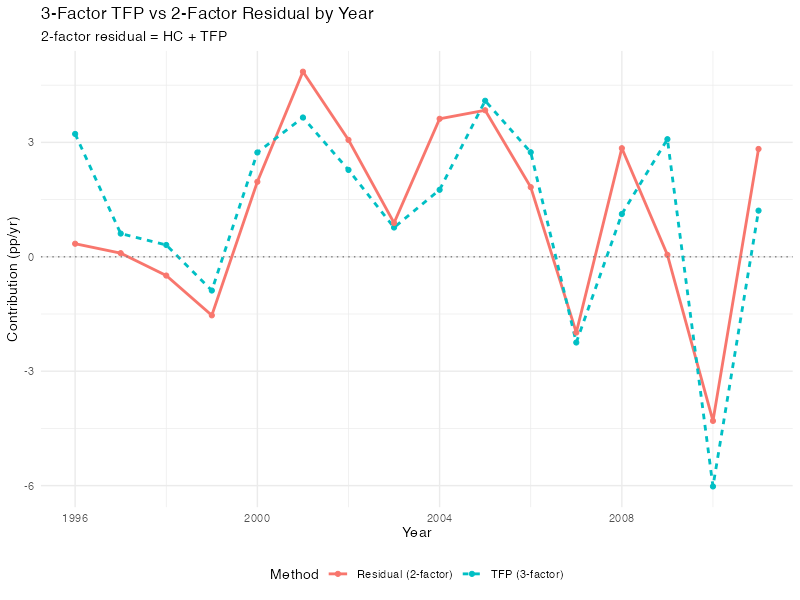

In [71]:
# Compare 3-factor TFP vs 2-factor residual by year
p <- year_tally |>
  pivot_longer(cols = c(tfp, tfp_2f), names_to = "method", values_to = "value") |>
  mutate(method = recode(method, tfp = "TFP (3-factor)", tfp_2f = "Residual (2-factor)")) |>
  ggplot(aes(x = year, y = value, colour = method, linetype = method)) +
  geom_line(linewidth = 1) +
  geom_point() +
  geom_hline(yintercept = 0, linetype = "dotted", colour = "gray50") +
  labs(title = "3-Factor TFP vs 2-Factor Residual by Year",
       subtitle = "2-factor residual = HC + TFP",
       x = "Year", y = "Contribution (pp/yr)", colour = "Method", linetype = "Method") +
  theme_minimal() +
  theme(legend.position = "bottom")
ggsave("output/figures/tfp_vs_2f_residual_by_year.png", p, width = 8, height = 5, dpi = 150)
p

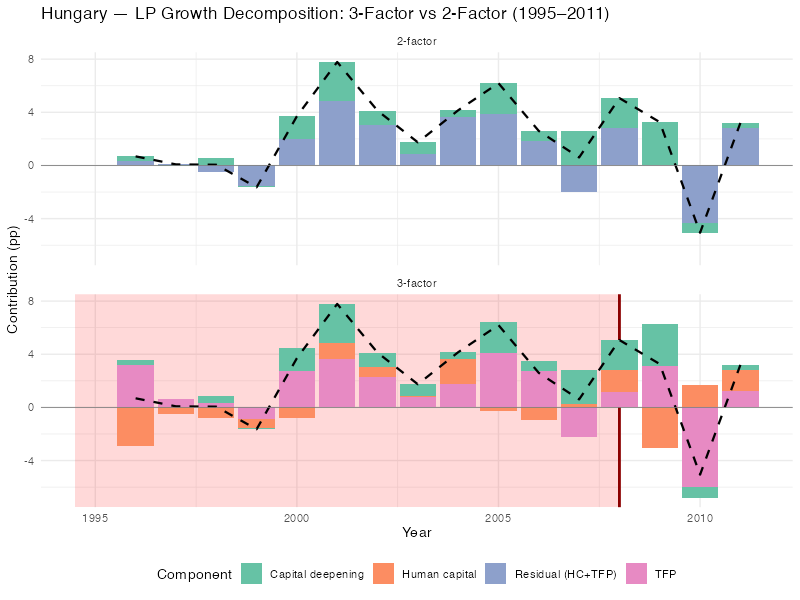

In [72]:
# Stacked bar: aggregate LP growth decomposition (1995–2011) — 3-factor and 2-factor
decomp_agg_plot <- decomp_df |>
  filter(!is.na(tfp_contrib)) |>
  group_by(year) |>
  summarise(
    cap = mean(cap_contrib, na.rm = TRUE),
    hc = mean(hc_contrib, na.rm = TRUE),
    tfp = mean(tfp_contrib, na.rm = TRUE),
    total = mean(g_y, na.rm = TRUE),
    cap_2f = mean(cap_contrib_2f, na.rm = TRUE),
    tfp_2f = mean(tfp_2f, na.rm = TRUE),
    .groups = "drop"
  )

stack_3f <- decomp_agg_plot |>
  select(year, cap, hc, tfp, total) |>
  pivot_longer(cols = c(cap, hc, tfp), names_to = "component", values_to = "contribution") |>
  mutate(component = recode(component, cap = "Capital deepening", hc = "Human capital", tfp = "TFP"), method = "3-factor")
stack_2f <- decomp_agg_plot |>
  select(year, cap_2f, tfp_2f, total) |>
  pivot_longer(cols = c(cap_2f, tfp_2f), names_to = "component", values_to = "contribution") |>
  mutate(component = recode(component, cap_2f = "Capital deepening", tfp_2f = "Residual (HC+TFP)"), method = "2-factor")
stack_agg <- bind_rows(stack_3f, stack_2f)

p <- ggplot(stack_agg, aes(x = year, y = contribution, fill = component)) +
  geom_rect(data = data.frame(method = "3-factor"),
            aes(xmin = 1994.5, xmax = 2008, ymin = -Inf, ymax = Inf),
            fill = "red", alpha = 0.15, inherit.aes = FALSE) +
  geom_vline(data = data.frame(method = "3-factor", xintercept = 2008),
             aes(xintercept = xintercept), linetype = "solid", colour = "darkred", linewidth = 1) +
  geom_col(position = "stack") +
  geom_line(data = decomp_agg_plot |> select(year, total) |> crossing(method = c("3-factor", "2-factor")), aes(x = year, y = total), inherit.aes = FALSE,
            colour = "black", linewidth = 0.8, linetype = "dashed") +
  geom_hline(yintercept = 0, colour = "grey50", linewidth = 0.3) +
  facet_wrap(~ method, ncol = 1) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Hungary — LP Growth Decomposition: 3-Factor vs 2-Factor (1995–2011)",
       x = "Year", y = "Contribution (pp)", fill = "Component") +
  theme_minimal() +
  theme(legend.position = "bottom")
ggsave("output/figures/lp_decomposition_aggregate_3f_and_2f.png", p, width = 8, height = 6, dpi = 150)
p

In [73]:
# full series built in "Merge & Build Full Series" section above

### Measurement choices

- **Capital:** `valKq_GFCF` is the quality-adjusted real capital stock from EUKLEMS. It adjusts for asset-type composition (ICT vs structures vs machinery) and is the theoretically preferred measure. An unweighted perpetual-inventory stock would attribute more ICT-intensive growth to TFP rather than capital deepening, overstating the Solow residual.

- **Human capital:** LAB_QI captures changes in workforce composition (education, age, gender) and is the best available proxy for $\hat{h}$. XGBoost backcasting extends coverage to 1995–2007; an alternative Mincerian index (e.g. Barro-Lee schooling) would allow full-period coverage but measures stock level rather than annual composition changes.

- **Labour input:** `total_hours = H_EMP × (EMP/EMPE)` incorporates the self-employed. Using employee hours alone would overstate output per hour in sectors with large self-employment (agriculture, construction, professional services).

## 6c. Question (d): Sectoral Decomposition

Average annual LP growth, capital deepening, human capital, and TFP by broad sector (1995–2011).

In [74]:
sect_avg <- decomp_df |>
  filter(!is.na(tfp_contrib)) |>
  group_by(nace_r2_code) |>
  summarise(
    lp_growth = mean(g_y, na.rm = TRUE),
    cap = mean(cap_contrib, na.rm = TRUE),
    hc = mean(hc_contrib, na.rm = TRUE),
    tfp = mean(tfp_contrib, na.rm = TRUE),
    cap_2f = mean(cap_contrib_2f, na.rm = TRUE),
    tfp_2f = mean(tfp_2f, na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(desc(lp_growth))

cat("--- Sectoral Tally Table (1995–2011) ---\n")
tbl_sect <- sect_avg |> mutate(across(where(is.numeric), ~round(., 2))) |>
  mutate(Sector = unname(sector_display_names[as.character(nace_r2_code)])) |>
  select(Sector, `LP Growth (pp)` = lp_growth, `Cap. Deepening (pp)` = cap, `HC (pp)` = hc, `TFP (pp)` = tfp, `Capital Deepening (pp)` = cap_2f, `TFP + HC Residual (pp)` = tfp_2f)
print(tbl_sect)
tbl_tex <- knitr::kable(tbl_sect, format = "latex", digits = 2, booktabs = TRUE)
writeLines(tbl_tex, "output/tables/sectoral_tally.tex")

# Export 2-factor and 3-factor subsets for LaTeX
tbl_sect_2f <- tbl_sect |> select(Sector, `LP Growth (pp)`, `Capital Deepening (pp)`, `TFP + HC Residual (pp)`)
tbl_tex_2f <- knitr::kable(tbl_sect_2f, format = "latex", digits = 2, booktabs = TRUE)
writeLines(tbl_tex_2f, "output/tables/sectoral_tally_2f.tex")

tbl_sect_3f <- tbl_sect |> select(Sector, `LP Growth (pp)`, `Cap. Deepening (pp)`, `HC (pp)`, `TFP (pp)`)
tbl_tex_3f <- knitr::kable(tbl_sect_3f, format = "latex", digits = 2, booktabs = TRUE)
writeLines(tbl_tex_3f, "output/tables/sectoral_tally_3f.tex")

# Sectoral 2-factor vs 3-factor comparison
sect_tfp_compare <- sect_avg |>
  mutate(Delta = tfp_2f - tfp) |>
  select(nace_r2_code, TFP_3f = tfp, Residual_2f = tfp_2f, Delta)
cat("\n--- Sectoral 2-Factor vs 3-Factor (TFP vs Residual) ---\n")
tbl_sect2f <- sect_tfp_compare |> mutate(across(where(is.numeric), ~round(., 2)))
print(tbl_sect2f)
tbl_tex <- knitr::kable(tbl_sect2f, format = "latex", digits = 2, booktabs = TRUE)
writeLines(tbl_tex, "output/tables/sectoral_2f_vs_3f.tex")

cat("\n--- Summary (d) ---\n")
cat(sprintf("Highest LP growth: %s (+%.2f pp/yr)\n", sect_avg$nace_r2_code[1], sect_avg$lp_growth[1]))
cat(sprintf("Lowest LP growth: %s (%.2f pp/yr)\n", sect_avg$nace_r2_code[nrow(sect_avg)], sect_avg$lp_growth[nrow(sect_avg)]))
sect_tfp <- sect_avg |> arrange(desc(tfp))
cat(sprintf("Highest TFP: %s (+%.2f pp/yr)\n", sect_tfp$nace_r2_code[1], sect_tfp$tfp[1]))
cat(sprintf("Lowest TFP: %s (%.2f pp/yr)\n", sect_tfp$nace_r2_code[nrow(sect_tfp)], sect_tfp$tfp[nrow(sect_tfp)]))

--- Sectoral Tally Table (1995–2011) ---
# A tibble: 14 × 7
   Sector                    `LP Growth (pp)` `Cap. Deepening (pp)` `HC (pp)` `TFP (pp)` Capital Deepening (p…¹
   <chr>                                <dbl>                 <dbl>     <dbl>      <dbl>                  <dbl>
 1 B – Mining & quarrying                9.99                  3.72      0.32       5.96                   3.72
 2 A – Agriculture                       5.58                  1.97     -0.22       3.83                   1.97
 3 J – ICT                               5.28                 -0.4      -0.96       6.64                  -0.4 
 4 C – Manufacturing                     5.13                  2.59      0.47       2.08                   2.59
 5 H – Transport & storage               3.31                  1.39      0.2        1.72                   1.39
 6 G – Wholesale & retail t…             2.73                  2.35     -0.42       0.79                   2.35
 7 O-Q – Public admin, educ…             2.3

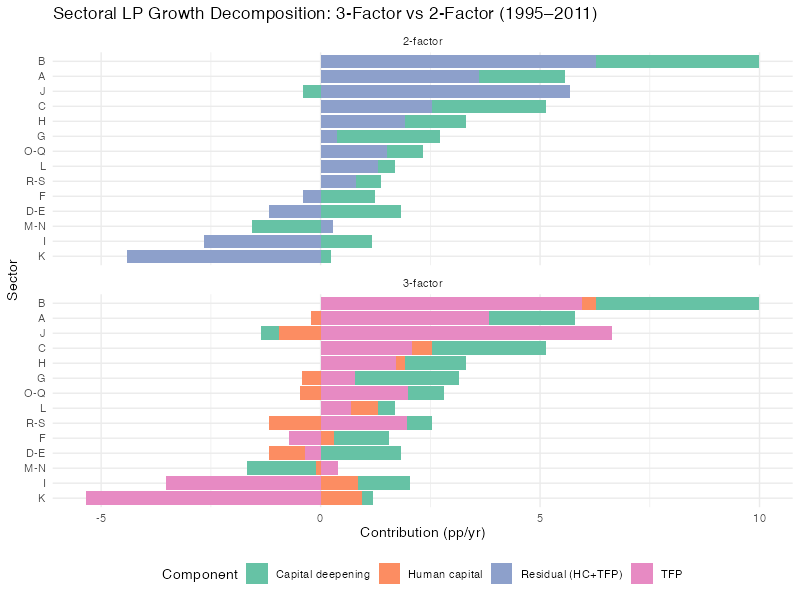

In [75]:
# Stacked bar: sectoral LP growth decomposition (1995–2011) — 3-factor and 2-factor
sect_stack_3f <- sect_avg |>
  mutate(nace_r2_code = fct_reorder(nace_r2_code, lp_growth)) |>
  select(nace_r2_code, lp_growth, cap, hc, tfp) |>
  pivot_longer(cols = c(cap, hc, tfp), names_to = "component", values_to = "contribution") |>
  mutate(component = recode(component, cap = "Capital deepening", hc = "Human capital", tfp = "TFP"), method = "3-factor")
sect_stack_2f <- sect_avg |>
  mutate(nace_r2_code = fct_reorder(nace_r2_code, lp_growth)) |>
  select(nace_r2_code, lp_growth, cap_2f, tfp_2f) |>
  pivot_longer(cols = c(cap_2f, tfp_2f), names_to = "component", values_to = "contribution") |>
  mutate(component = recode(component, cap_2f = "Capital deepening", tfp_2f = "Residual (HC+TFP)"), method = "2-factor")
sect_stack <- bind_rows(sect_stack_3f, sect_stack_2f)

p <- ggplot(sect_stack, aes(x = nace_r2_code, y = contribution, fill = component)) +
  geom_col(position = "stack") +
  coord_flip() +
  facet_wrap(~ method, ncol = 1) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Sectoral LP Growth Decomposition: 3-Factor vs 2-Factor (1995–2011)",
       x = "Sector", y = "Contribution (pp/yr)", fill = "Component") +
  theme_minimal() +
  theme(legend.position = "bottom")
ggsave("output/figures/sectoral_lp_decomposition_3f_and_2f.png", p, width = 8, height = 8, dpi = 150)
p

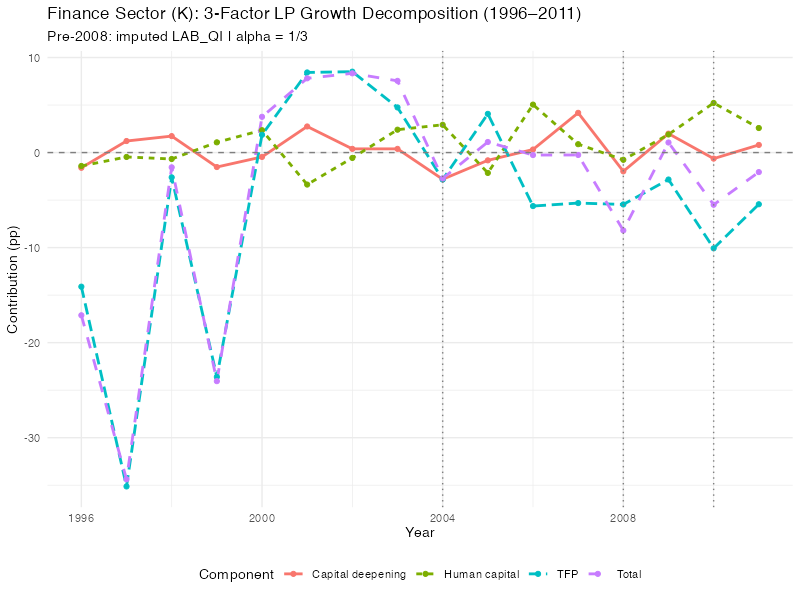

In [76]:
# Finance sector (K): 3-factor LP growth decomposition (1996–2011)
fin_K <- decomp_df |>
  filter(nace_r2_code == "K", !is.na(tfp_contrib)) |>
  transmute(
    year,
    cap = cap_contrib,
    hc = hc_contrib,
    tfp = tfp_contrib,
    total = g_y
  )

fin_K_long <- fin_K |>
  select(year, cap, hc, tfp, total) |>
  pivot_longer(-year, names_to = "component", values_to = "contrib") |>
  mutate(component = recode(component,
    cap = "Capital deepening",
    hc = "Human capital",
    tfp = "TFP",
    total = "Total"
  ))

events <- data.frame(year = c(2004, 2008, 2010), event = c("EU Accession", "GFC", "Orban gov"))

p <- ggplot(fin_K_long, aes(x = year, y = contrib, colour = component, linetype = component)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey50") +
  geom_vline(data = events, aes(xintercept = year), linetype = "dotted", colour = "grey50", linewidth = 0.5) +
  geom_text(data = events, aes(x = year, y = Inf, label = event), vjust = -0.5, size = 2.5, colour = "grey40", inherit.aes = FALSE) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.12))) +
  labs(
    title = "Finance Sector (K): 3-Factor LP Growth Decomposition (1996–2011)",
    subtitle = "Pre-2008: imputed LAB_QI | alpha = 1/3",
    x = "Year", y = "Contribution (pp)",
    colour = "Component", linetype = "Component"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")
ggsave("output/figures/finance_sector_K_3f_decomposition.png", p, width = 8, height = 6, dpi = 150)
p

## 6d. Question (e): Sector-Specific α

Labour share LS = COMP/VA_CP (averaged across years). Implied capital share α_s = 1 − LS. Recompute decomposition with sector-specific α and compare TFP.

In [77]:
# Step 1: Labour share by sector (averaged across years)
lab_share <- fp |>
  filter(nace_r2_code %in% broad_sectors, year >= 1995, year <= 2011) |>
  group_by(nace_r2_code) |>
  summarise(
    lab_share = mean(valCOMP / valVA_CP, na.rm = TRUE),
    .groups = "drop"
  ) |>
  mutate(alpha_s = 1 - lab_share)

cat("Labour share and implied alpha_s by sector:\n")
tbl_lab <- lab_share |> mutate(across(where(is.numeric), ~round(., 3))) |>
  mutate(Sector = unname(sector_display_names[as.character(nace_r2_code)])) |>
  select(Sector, `Labour Share (1-α_s)` = lab_share, `Implied α_s` = alpha_s)
print(tbl_lab)
tbl_tex <- knitr::kable(tbl_lab, format = "latex", digits = 3, booktabs = TRUE)
writeLines(tbl_tex, "output/tables/lab_share_alpha.tex")

Labour share and implied alpha_s by sector:
# A tibble: 14 × 3
   Sector                                `Labour Share (1-α_s)` `Implied α_s`
   <chr>                                                  <dbl>         <dbl>
 1 A – Agriculture                                        0.29          0.71 
 2 B – Mining & quarrying                                 0.59          0.41 
 3 C – Manufacturing                                      0.511         0.489
 4 D-E – Utilities                                        0.465         0.535
 5 F – Construction                                       0.518         0.482
 6 G – Wholesale & retail trade                           0.591         0.409
 7 H – Transport & storage                                0.627         0.373
 8 I – Accommodation & food                               0.599         0.401
 9 J – ICT                                                0.433         0.567
10 K – Finance & insurance                                0.497         0.503
1

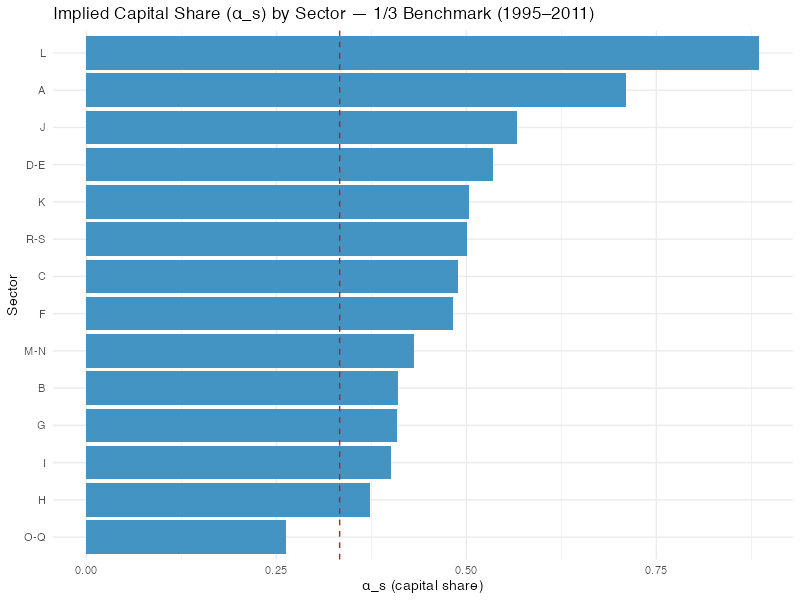

In [78]:
# Bar chart: implied capital share (α_s) by sector — 1/3 benchmark
p <- ggplot(lab_share, aes(x = fct_reorder(nace_r2_code, alpha_s), y = alpha_s)) +
  geom_col(fill = "#4393c3") +
  geom_hline(yintercept = 1/3, linetype = "dashed", colour = "firebrick") +
  coord_flip() +
  labs(title = "Implied Capital Share (α_s) by Sector — 1/3 Benchmark (1995–2011)",
       x = "Sector", y = "α_s (capital share)") +
  theme_minimal()
ggsave("output/figures/implied_capital_share_by_sector.png", p, width = 8, height = 5, dpi = 150)
p

In [79]:
# Step 2: Recompute decomposition with sector-specific alpha (3-factor and 2-factor)
decomp_alpha <- decomp_df |>
  left_join(lab_share |> select(nace_r2_code, alpha_s), by = "nace_r2_code") |>
  mutate(
    cap_contrib_s = (alpha_s / (1 - alpha_s)) * (g_K - g_L),
    tfp_contrib_s = g_y - cap_contrib_s - hc_contrib,
    cap_contrib_s_2f = cap_contrib_s,
    tfp_contrib_s_2f = g_y - cap_contrib_s
  )

sect_avg_alpha <- decomp_alpha |>
  filter(!is.na(tfp_contrib_s)) |>
  group_by(nace_r2_code) |>
  summarise(
    tfp_alpha_s = mean(tfp_contrib_s, na.rm = TRUE),
    tfp_alpha_s_2f = mean(tfp_contrib_s_2f, na.rm = TRUE),
    .groups = "drop"
  )

In [80]:
# Step 3: Compare TFP (alpha=1/3 vs sector-specific alpha) — 3-factor and 2-factor
tfp_compare <- sect_avg |>
  select(nace_r2_code, tfp_alpha_13 = tfp, tfp_2f) |>
  left_join(sect_avg_alpha, by = "nace_r2_code") |>
  mutate(delta_tfp = tfp_alpha_s - tfp_alpha_13)

cat("TFP comparison: alpha=1/3 vs sector-specific alpha (3-factor and 2-factor)\n")
tbl_tfp <- tfp_compare |> mutate(across(where(is.numeric), ~round(., 2))) |>
  mutate(Sector = unname(sector_display_names[as.character(nace_r2_code)])) |>
  select(Sector, `TFP (α=1/3)` = tfp_alpha_13, `TFP (sector α_s)` = tfp_alpha_s, `Difference (pp)` = delta_tfp)
print(tbl_tfp)
tbl_tex <- knitr::kable(tbl_tfp, format = "latex", digits = 2, booktabs = TRUE)
writeLines(tbl_tex, "output/tables/tfp_compare.tex")

# Rankings: do they change?
rank_13 <- sect_avg |> arrange(desc(tfp)) |> mutate(rank_13 = row_number()) |> select(nace_r2_code, rank_13)
rank_s  <- sect_avg_alpha |> arrange(desc(tfp_alpha_s)) |> mutate(rank_s = row_number()) |> select(nace_r2_code, rank_s)
rank_diff <- rank_13 |> full_join(rank_s, by = "nace_r2_code") |> mutate(rank_change = rank_s - rank_13)
cat("\n--- Conclusion (e) ---\n")
cat("Rankings preserved:", all(rank_diff$rank_change == 0), "\n")
cat("Sectors with largest TFP shift (|delta| > 0.3 pp):\n")
print(tfp_compare |> filter(abs(delta_tfp) > 0.3) |> select(nace_r2_code, tfp_alpha_13, tfp_alpha_s, delta_tfp))

TFP comparison: alpha=1/3 vs sector-specific alpha (3-factor and 2-factor)
# A tibble: 14 × 4
   Sector                                `TFP (α=1/3)` `TFP (sector α_s)` `Difference (pp)`
   <chr>                                         <dbl>              <dbl>             <dbl>
 1 B – Mining & quarrying                         5.96               4.5              -1.46
 2 A – Agriculture                                3.83              -3.87             -7.69
 3 J – ICT                                        6.64               7.29              0.65
 4 C – Manufacturing                              2.08              -0.29             -2.37
 5 H – Transport & storage                        1.72               1.46             -0.26
 6 G – Wholesale & retail trade                   0.79              -0.11             -0.91
 7 O-Q – Public admin, education, health          1.99               2.23              0.23
 8 L – Real estate                                0.69              -4.87     

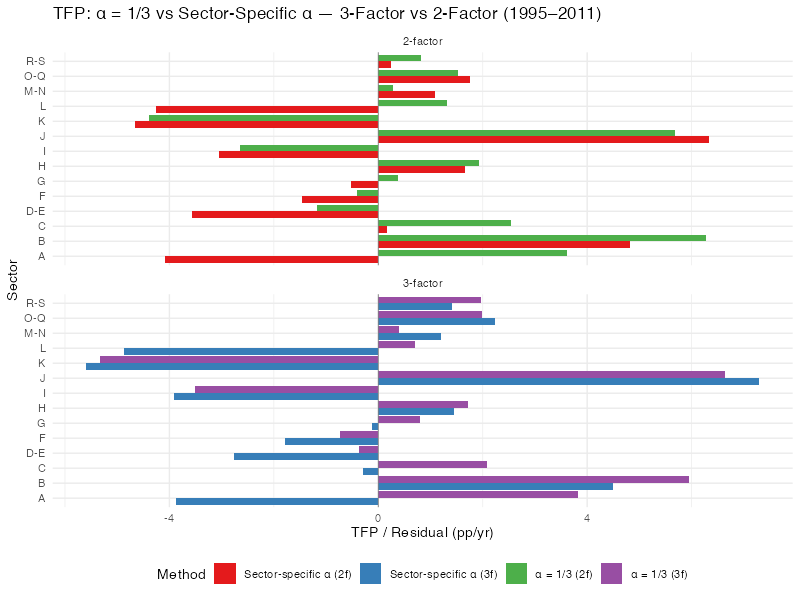

In [81]:
# Bar chart: TFP comparison — α = 1/3 vs sector-specific α (3-factor and 2-factor)
tfp_plot <- tfp_compare |>
  pivot_longer(cols = c(tfp_alpha_13, tfp_alpha_s, tfp_2f, tfp_alpha_s_2f), names_to = "method", values_to = "tfp") |>
  mutate(
    method = recode(method,
      tfp_alpha_13 = "α = 1/3 (3f)",
      tfp_alpha_s = "Sector-specific α (3f)",
      tfp_2f = "α = 1/3 (2f)",
      tfp_alpha_s_2f = "Sector-specific α (2f)"
    ),
    factor_type = if_else(grepl("3f", method), "3-factor", "2-factor")
  )
p <- ggplot(tfp_plot, aes(x = nace_r2_code, y = tfp, fill = method)) +
  geom_col(position = "dodge") +
  geom_hline(yintercept = 0, colour = "grey50", linewidth = 0.3) +
  coord_flip() +
  facet_wrap(~ factor_type, ncol = 1) +
  scale_fill_brewer(palette = "Set1") +
  labs(title = "TFP: α = 1/3 vs Sector-Specific α — 3-Factor vs 2-Factor (1995–2011)",
       x = "Sector", y = "TFP / Residual (pp/yr)", fill = "Method") +
  theme_minimal() +
  theme(legend.position = "bottom")
ggsave("output/figures/tfp_alpha_comparison_3f_and_2f.png", p, width = 8, height = 8, dpi = 150)
p

## 6. Graphs: Imputed vs Observed HC Movement

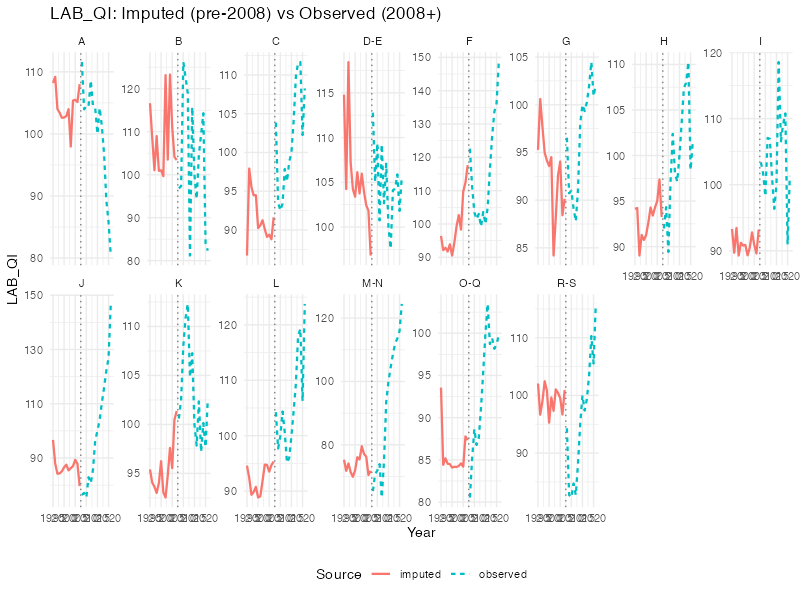

In [82]:
# Graph 1: LAB_QI levels over time by sector (imputed vs observed)
p <- ggplot(full, aes(x = year, y = valueLAB_QI, colour = source, linetype = source)) +
  geom_line(linewidth = 0.8) +
  geom_vline(xintercept = 2007.5, linetype = "dotted", colour = "grey50") +
  facet_wrap(~nace_r2_code, scales = "free_y", ncol = 8) +
  labs(title = "LAB_QI: Imputed (pre-2008) vs Observed (2008+)",
       x = "Year", y = "LAB_QI", colour = "Source", linetype = "Source") +
  theme_minimal() +
  theme(legend.position = "bottom")
ggsave("output/figures/labqi_imputed_vs_observed_full.png", p, width = 10, height = 6, dpi = 150)
p

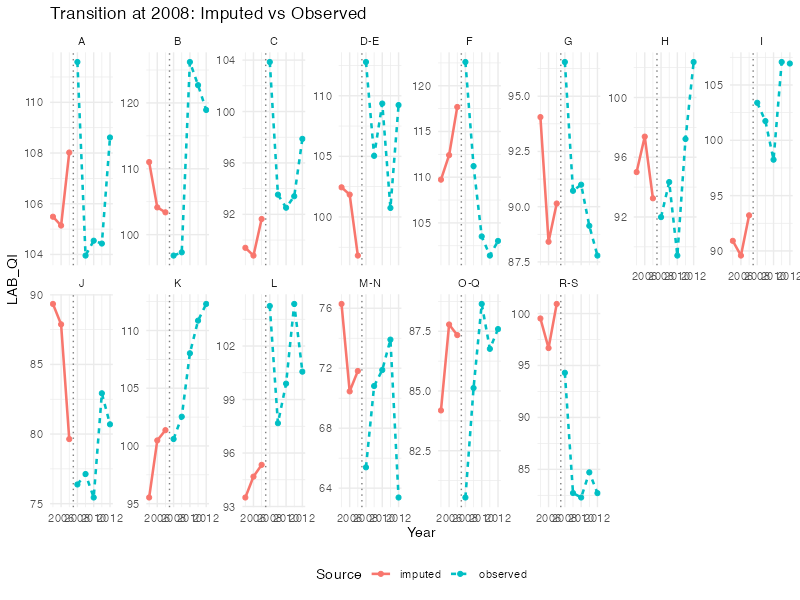

In [83]:
# Graph 2: Transition zoom (2005-2012) — continuity at 2008
full_zoom <- full[year >= 2005 & year <= 2012]
p <- ggplot(full_zoom, aes(x = year, y = valueLAB_QI, colour = source, linetype = source)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 1.5) +
  geom_vline(xintercept = 2007.5, linetype = "dotted", colour = "grey50") +
  facet_wrap(~nace_r2_code, scales = "free_y", ncol = 8) +
  labs(title = "Transition at 2008: Imputed vs Observed",
       x = "Year", y = "LAB_QI", colour = "Source", linetype = "Source") +
  theme_minimal() +
  theme(legend.position = "bottom")
ggsave("output/figures/labqi_transition_zoom.png", p, width = 10, height = 6, dpi = 150)
p

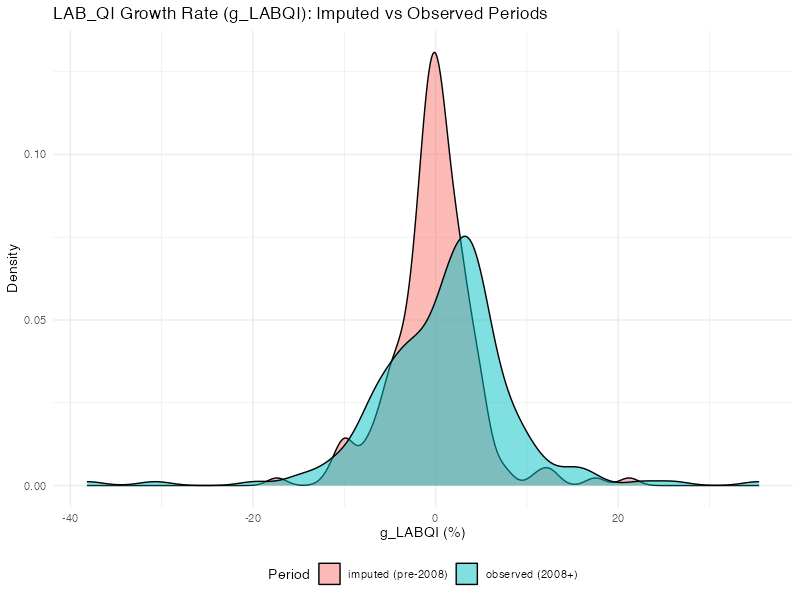

In [84]:
# Graph 3: Growth rate (g_LABQI) distribution — imputed vs observed periods
full$period <- ifelse(full$year < 2008, "imputed (pre-2008)", "observed (2008+)")
g_plot <- full[!is.na(g_LABQI) & is.finite(g_LABQI)]

p <- ggplot(g_plot, aes(x = g_LABQI, fill = period)) +
  geom_density(alpha = 0.5) +
  labs(title = "LAB_QI Growth Rate (g_LABQI): Imputed vs Observed Periods",
       x = "g_LABQI (%)", y = "Density", fill = "Period") +
  theme_minimal() +
  theme(legend.position = "bottom")
ggsave("output/figures/labqi_growth_distribution.png", p, width = 8, height = 5, dpi = 150)
p

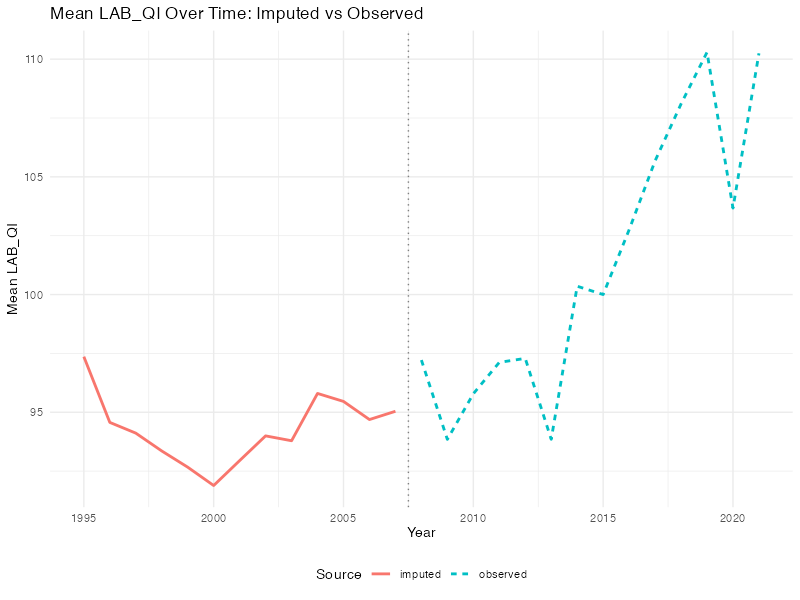

In [85]:
# Graph 4: Aggregate mean LAB_QI over time (all industries)
agg <- full[, .(mean_LAB_QI = mean(valueLAB_QI, na.rm = TRUE), n = .N), by = .(year, source)]

p <- ggplot(agg, aes(x = year, y = mean_LAB_QI, colour = source, linetype = source)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = 2007.5, linetype = "dotted", colour = "grey50") +
  labs(title = "Mean LAB_QI Over Time: Imputed vs Observed",
       x = "Year", y = "Mean LAB_QI", colour = "Source", linetype = "Source") +
  theme_minimal() +
  theme(legend.position = "bottom")
ggsave("output/figures/labqi_mean_over_time.png", p, width = 8, height = 5, dpi = 150)
p

## 7. Export

In [86]:
# Merge imputed values back into full panel
imp_export <- pred_df[, .(nace_r2_code, year, valueLAB_QI_imputed)]
fp_merged <- merge(fp, imp_export, by = c("nace_r2_code", "year"), all.x = TRUE)
fp_merged[is.na(valueLAB_QI), valueLAB_QI := valueLAB_QI_imputed]
fp_merged[, valueLAB_QI_imputed := NULL]

fwrite(fp_merged, "Data/panel_with_labqi_backcast.csv")
cat("Saved Data/panel_with_labqi_backcast.csv\n")

Saved Data/panel_with_labqi_backcast.csv
